In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

col_names = ['mpg', 'cylinders', 'displacement', 'horsepower',
             'weight', 'acceleration', 'model_year', 'origin', 'car_name']

df = pd.read_csv(url, names=col_names, sep=r'\s+', na_values='?')

df = df.drop(columns=['car_name'])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (398, 8)

First 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [4]:
df.describe().round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.00,398.00,398.00,392.00,398.00,398.00,398.00,398.00
mean,23.51,5.45,193.43,104.47,2970.42,15.57,76.01,1.57
std,7.82,1.70,104.27,38.49,846.84,2.76,3.70,0.80
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00,1.00
25%,17.50,4.00,104.25,75.00,2223.75,13.82,73.00,1.00
50%,23.00,4.00,148.50,93.50,2803.50,15.50,76.00,1.00
75%,29.00,8.00,262.00,126.00,3608.00,17.18,79.00,2.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00,3.00


In [5]:
print(df.isnull().sum())
print(df["horsepower"].isnull().sum())
print(f"{df['horsepower'].isnull().mean() * 100:.2f}")

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64
6
1.51


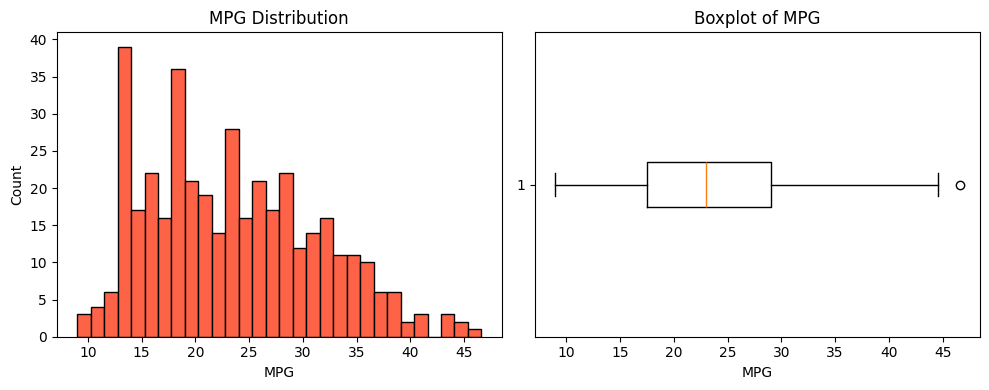

In [6]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df["mpg"], bins=30, color="Tomato", edgecolor="black")
plt.title("MPG Distribution")
plt.xlabel("MPG")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.boxplot(df["mpg"], vert=False, )
plt.title("Boxplot of MPG")
plt.xlabel("MPG")

plt.tight_layout()
plt.show()

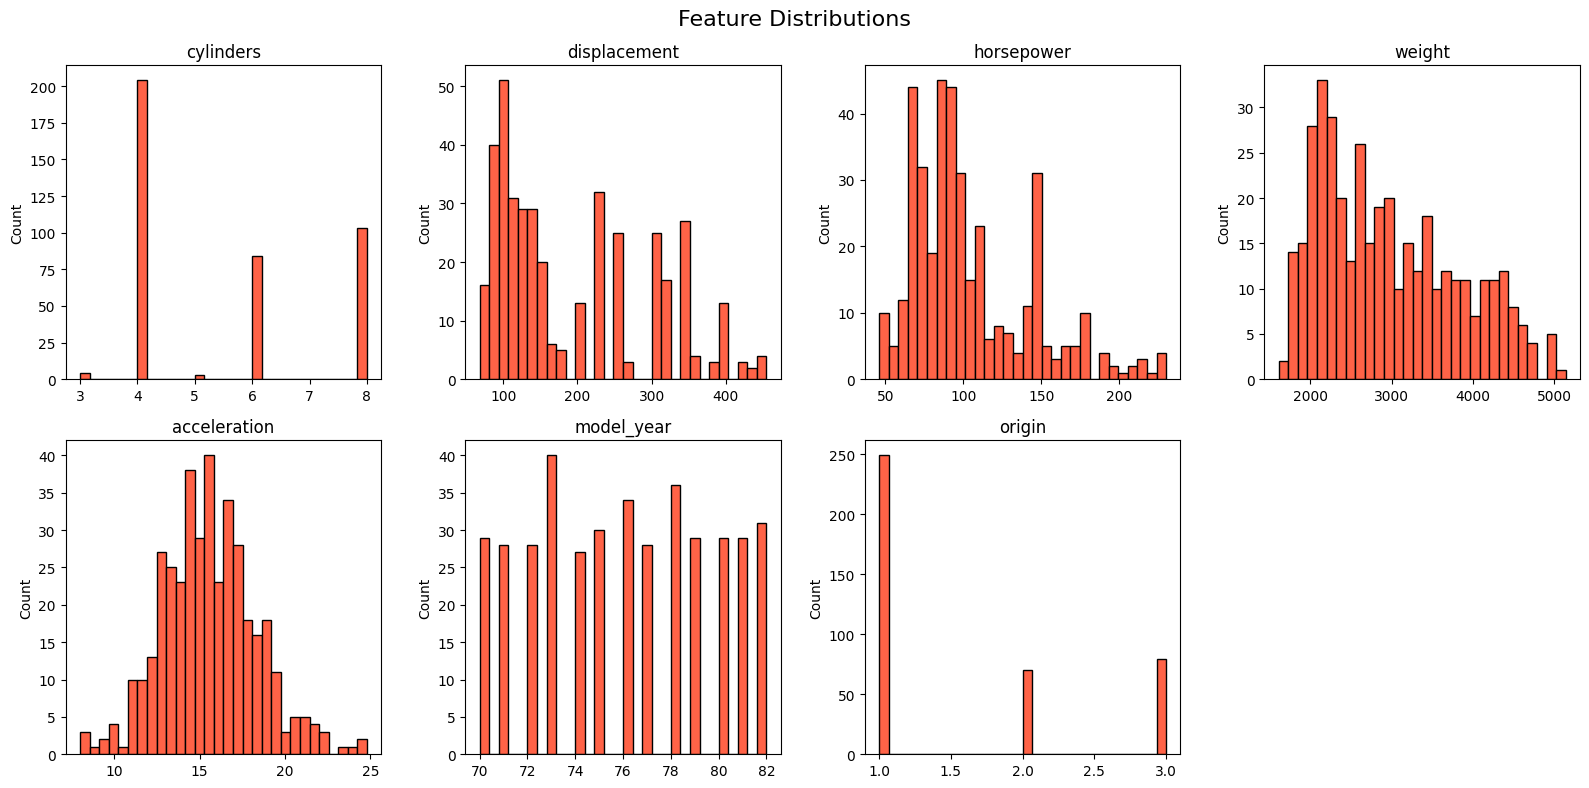

In [7]:
features = ['cylinders', 'displacement', 'horsepower',
            'weight', 'acceleration', 'model_year', 'origin']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(features):
    ax = axes[i // 4, i % 4]
    ax.hist(df[col].dropna(), bins=30, color="tomato", edgecolor="black")
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.suptitle("Feature Distributions", fontsize=16)
axes[1, 3].set_visible(False)
plt.tight_layout()


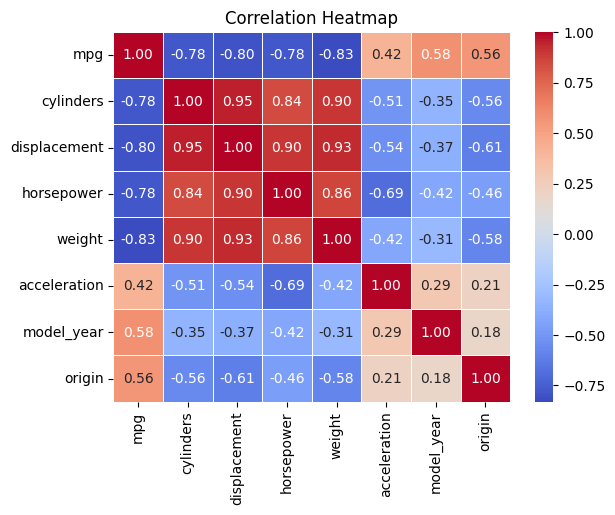

In [8]:
plt.Figure(figsize=(10, 8))
corr = df.corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

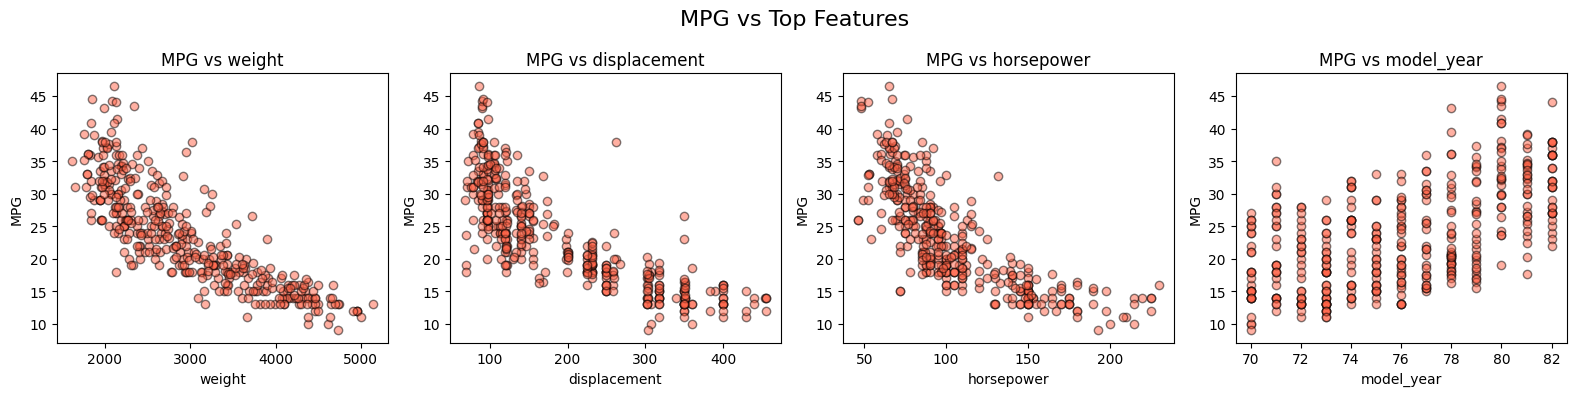

In [9]:
top_features = ['weight', 'displacement', 'horsepower', 'model_year']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df['mpg'], alpha=0.5, color="Tomato", edgecolor="black")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('MPG')
    axes[i].set_title(f'MPG vs {col}')

plt.suptitle("MPG vs Top Features", fontsize=16)
plt.tight_layout()
plt.show()    

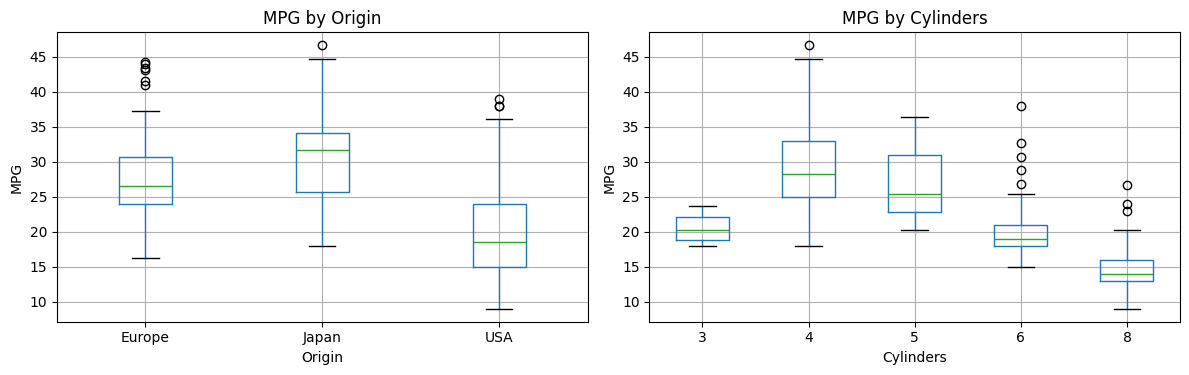

In [10]:
plt.figure(figsize=(12, 4))

# Left: MPG by Origin
plt.subplot(1, 2, 1)
origin_labels = {1: 'USA', 2: 'Europe', 3: 'Japan'}
df['origin_label'] = df['origin'].map(origin_labels)
df.boxplot(column='mpg', by='origin_label', ax=plt.gca())
plt.title('MPG by Origin')
plt.suptitle('')
plt.xlabel('Origin')
plt.ylabel('MPG')

# Right: MPG by Cylinders
plt.subplot(1, 2, 2)
df.boxplot(column='mpg', by='cylinders', ax=plt.gca())
plt.title('MPG by Cylinders')
plt.suptitle('')
plt.xlabel('Cylinders')
plt.ylabel('MPG')

plt.tight_layout()
plt.show()

In [12]:
print(df["horsepower"].isnull().sum())

median_hp = df['horsepower'].median()
df["horsepower"] = df['horsepower'].fillna(median_hp)

print(df["horsepower"].isnull().sum())
print(median_hp)



6
0
93.5


In [14]:
print("Before encoding")
print(df["origin"].value_counts())
print(list(df.columns))
print()

df = pd.get_dummies(df, columns=["origin"], prefix='origin', dtype=int)

print("After encoding")
print(list(df.columns))

Before encoding
origin
1    249
3     79
2     70
Name: count, dtype: int64
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'origin_label']

After encoding
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_label', 'origin_1', 'origin_2', 'origin_3']


In [19]:
if 'origin_label' in df.columns:
    df = df.drop(columns=['origin_label'])
    print("Dropped origin_label")

print("Columns after drop:", df.columns.tolist())
X = df.drop(columns=["mpg"])
Y = df["mpg"]

print("Features:", list(X.columns))
print(X.shape, Y.shape)

Dropped origin_label
Columns after drop: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_1', 'origin_2', 'origin_3']
Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_1', 'origin_2', 'origin_3']
(398, 9) (398,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_test.shape, Y_test.shape)

(80, 9) (80,)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.mean().round(2))
print(X_test_scaled.std().round(2))

-0.0
1.04
